# Computational Statistical Mechanics - pamuduamarasinghe

# Monte Carlo Simulations  

Monte Carlo methods can be described as a collection of computational techniques for
obtaining an approximate solution to mathematical problems using random samples

# 1) 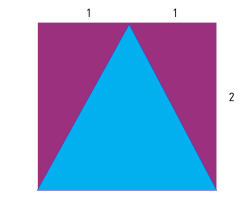

Calculating the ratio 𝑆. (ratio of areas of blue traingle with complete square)


In [33]:
import numpy as np

def ratio_s(N):
    in_triangle = 0
    #random points in [0,1] x [0,1]
    for i in range(N):
        x = np.random.uniform(0, 2)
        y = np.random.uniform(0, 2)

        #consider straight line equation joining vertices
        if y <= 2*x and y <= -2*x + 4:
            in_triangle += 1

    s = in_triangle / N

    # Variance: p(1-p)/n for Bernoulli trials
    var = s * (1 - s) / N

    return s, var


print("Analytical Value S = 0.5\n")

iterations = [10,100,1000,5000,10000]

print("Iterations | Estimated S | Variance")
for n in iterations:
    s, var = ratio_s(n)
    print(f"{n:10d} | {s:11.6f} | {var:.8f}")

Analytical Value S = 0.5

Iterations | Estimated S | Variance
        10 |    0.700000 | 0.02100000
       100 |    0.490000 | 0.00249900
      1000 |    0.494000 | 0.00024996
      5000 |    0.490200 | 0.00004998
     10000 |    0.502800 | 0.00002500


# 2) Two six sided dice roll

In [34]:
#probability of getting 4 in single die

import numpy as np

def single_die(N):
    roll = np.random.randint(1,7,N)
    is_four = (roll ==4)
    prob_4 = np.sum(is_four)/N

    p = prob_4
    var = p*(1-p)/N

    return p , var


iterations = [10,100,1000,5000,10000]

print("probability of getting 4 in single die")
print("Iterations | Estimated P | Variance")
for n in iterations:
    p, var = single_die(n)
    print(f"{n:10d} | {p:11.6f} | {var:.8f}")



probability of getting 4 in single die
Iterations | Estimated P | Variance
        10 |    0.100000 | 0.00900000
       100 |    0.130000 | 0.00113100
      1000 |    0.168000 | 0.00013978
      5000 |    0.160800 | 0.00002699
     10000 |    0.168300 | 0.00001400


In [35]:
#probability of getting two sixes from dice rolling

import numpy as np

def two_sixes(N):

    die1 = np.random.randint(1, 7, N)
    die2 = np.random.randint(1, 7, N)

    win = (die1 == 6) & (die2 == 6)

    P = np.sum(win) / N

    Var = P * (1 - P) / N

    return P, Var


print("Analytical Probability =", 1/36)

iterations = [10, 100, 1000, 5000, 10000, 100000]

print("Iterations | Estimated P | Variance")

for n in iterations:
    P, Var = two_sixes(n)
    print(f"{n:10d} | {P:11.6f} | {Var:.8f}")




Analytical Probability = 0.027777777777777776
Iterations | Estimated P | Variance
        10 |    0.100000 | 0.00900000
       100 |    0.010000 | 0.00009900
      1000 |    0.037000 | 0.00003563
      5000 |    0.027200 | 0.00000529
     10000 |    0.028500 | 0.00000277
    100000 |    0.027810 | 0.00000027


In [36]:
#probability of getting sum = 6 from dice rolling

import numpy as np

def two_sixes(N):

    die1 = np.random.randint(1, 7, N)
    die2 = np.random.randint(1, 7, N)

    win = (die1+die2 ==6 )

    P = np.sum(win) / N

    Var = P * (1 - P) / N

    return P, Var


print("Analytical Probability =", 5/36)

iterations = [10, 100, 1000, 5000, 10000, 100000]

print("Iterations | Estimated P | Variance")

for n in iterations:
    P, Var = two_sixes(n)
    print(f"{n:10d} | {P:11.6f} | {Var:.8f}")


Analytical Probability = 0.1388888888888889
Iterations | Estimated P | Variance
        10 |    0.200000 | 0.01600000
       100 |    0.180000 | 0.00147600
      1000 |    0.132000 | 0.00011458
      5000 |    0.131000 | 0.00002277
     10000 |    0.131400 | 0.00001141
    100000 |    0.138540 | 0.00000119


# 3) Markov-chain Monte Carlo Simulations

In Markov-chain we are generating a sequence of random variables, where the current value is probabilistically relied
on the value of the previous variable.

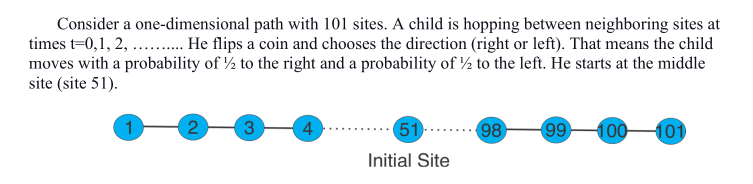

In [37]:
import numpy as np

def Markov_random_walk(N, start=51):

    position = start

    for i in range(N):

        move = 1 if np.random.random() < 0.5 else -1
        position += move

        # Prevent leaving the path
        if position < 1:
            position = 1
        elif position > 101:
            position = 101

    return position == 101


def Markov_prob(N, simulations=10000):

    success = 0

    for i in range(simulations):

        if Markov_random_walk(N):
            success += 1

    P = success / simulations
    Var = P * (1 - P) / simulations

    return P, Var


iterations = [10, 60, 100, 200, 500, 800, 1000]

print("Probability of being at site 101 after N steps")
print("Steps | Estimated P | Variance")

for n in iterations:

    P, Var = Markov_prob(n)
    print(f"{n:5d} | {P:11.6f} | {Var:.8f}")

Probability of being at site 101 after N steps
Steps | Estimated P | Variance
   10 |    0.000000 | 0.00000000
   60 |    0.000000 | 0.00000000
  100 |    0.000000 | 0.00000000
  200 |    0.000000 | 0.00000000
  500 |    0.003700 | 0.00000037
  800 |    0.005900 | 0.00000059
 1000 |    0.007900 | 0.00000078
